# Example climb: save the princess

**Goal**: maximize the probability of a cure while using the least total ingredients

## 1. Notebook setup

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

sys.path.append('..')

from hill_climber import HillClimber

np.random.seed(315)

## 2. Potion model

### 2.1. Data preparation

In [2]:
df = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit3/Cure_the_princess.csv')

train_df, test_df = train_test_split(df)
train_df.info()    

<class 'pandas.core.frame.DataFrame'>
Index: 1753 entries, 2137 to 611
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Phoenix Feather  1753 non-null   float64
 1   Unicorn Horn     1753 non-null   float64
 2   Dragon's Blood   1753 non-null   float64
 3   Mermaid Tears    1753 non-null   float64
 4   Fairy Dust       1753 non-null   float64
 5   Goblin Toes      1753 non-null   float64
 6   Witch's Brew     1753 non-null   float64
 7   Griffin Claw     1753 non-null   float64
 8   Troll Hair       1753 non-null   float64
 9   Kraken Ink       1753 non-null   float64
 10  Minotaur Horn    1753 non-null   float64
 11  Basilisk Scale   1753 non-null   float64
 12  Chimera Fang     1753 non-null   float64
 13  Cured            1753 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 205.4 KB


### 2.2. Model training

In [3]:
model = GradientBoostingClassifier()
_ = model.fit(train_df.drop(columns=['Cured']), train_df['Cured'])

### 2.3. Model evaluation

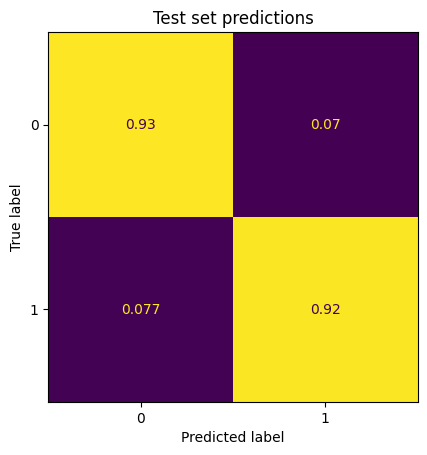

In [4]:
predictions = model.predict(test_df.drop(columns=['Cured']))

ConfusionMatrixDisplay.from_predictions(
    test_df['Cured'],
    predictions,
    normalize='true',
    colorbar=False
)

plt.title('Test set predictions')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

### 2.4. Retrain with complete dataset

In [5]:
_ = model.fit(df.drop(columns=['Cured']), df['Cured'])

## 3. Find best potion

### 3.1. Starting potion

In [6]:
# Get max ingredient values from the dataset
max_values = df.drop(columns='Cured').describe().loc['max']
max_values

Phoenix Feather    42.1
Unicorn Horn       34.1
Dragon's Blood     40.8
Mermaid Tears      35.8
Fairy Dust         40.4
Goblin Toes        37.8
Witch's Brew       37.3
Griffin Claw       39.4
Troll Hair         44.8
Kraken Ink         39.5
Minotaur Horn      33.7
Basilisk Scale     42.0
Chimera Fang       37.8
Name: max, dtype: float64

In [7]:
# Create a random starting potion where each ingredient is between 0 and its max value
starting_potion = {}

for feature, value in max_values.items():
    starting_potion[feature] = [np.random.uniform(0, max_values.loc[feature])]

starting_potion_df = pd.DataFrame(starting_potion)
starting_potion_df

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang
0,32.316773,2.974719,25.788348,19.17993,33.715806,34.298547,23.000576,35.818569,21.774855,12.140236,27.197326,40.383144,27.155311


### 3.2. Hill climbing objective function

In [8]:
# Get total max value sum for all ingredients. Will be used to calculate a
# penalty term based on total ingredient values in the potion.
total_max_value = max_values.sum()
print(f'Combined max value for all ingredients: {total_max_value}')

Combined max value for all ingredients: 505.5


In [9]:
# Get feature names
features = max_values.index.tolist()
print(f'Features: {features}')

Features: ['Phoenix Feather', 'Unicorn Horn', "Dragon's Blood", 'Mermaid Tears', 'Fairy Dust', 'Goblin Toes', "Witch's Brew", 'Griffin Claw', 'Troll Hair', 'Kraken Ink', 'Minotaur Horn', 'Basilisk Scale', 'Chimera Fang']


In [10]:
def score_potion(*args):

    global features
    global model
    global total_max_value

    # Stack columns horizontally to create DataFrame
    potion_df = pd.DataFrame(
        np.column_stack(args),
        columns=features
    )

    # Predict cure probability
    cure_probability = model.predict_proba(potion_df)[0, 1]

    # Calculate total ingredient penalty
    ingredient_sum = potion_df.sum(axis=1).values[0]
    penalty = ingredient_sum / total_max_value
    
    # Return metrics dict and objective value
    metrics = {
        'Cure probability': cure_probability,
        'Ingredient penalty': penalty
    }
    
    objective = cure_probability - penalty

    return metrics, objective

### 3.3. Hill climb optimization

In [ ]:
climber = HillClimber(
    data=starting_potion_df,
    objective_func=score_potion,
    step_spread=0.25,
    T_min=0.0001,
    T_max=0.01,
    cooling_rate=1e-10,
    exchange_interval=100,
    max_time=5,
    mode='maximize',
    n_replicas=5,
    db_enabled=True,
    db_path='../data/princess.db',
    db_step_interval=10
)

# Create bounds tuple from 0 to max_values
lower_bounds = np.zeros(len(max_values))
upper_bounds = max_values.values

# Override the bounds that were auto-calculated from the single-row data
climber.bounds = (lower_bounds, upper_bounds)

# Run optimization
best_data = climber.climb()

In [19]:
best_data

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang
0,0.354292,0.261974,0.957837,0.22942,0.506522,0.138539,25.509144,0.039513,0.196885,0.01459,0.017074,0.510621,0.043694


In [ ]:
# View the best result as a DataFrame
pd.DataFrame(best_data, columns=features)

metric_name,perturbation_num,Cure probability,Ingredient penalty
0,0,0.279559,0.664168
1,2,0.279559,0.663314
2,13,0.279559,0.662895
3,16,0.279559,0.662109
4,17,0.279559,0.661421


In [21]:
# Collect best data from all replicas
all_best_data = []

for i, replica in enumerate(climber.replicas):
    data_dict = {f'col_{j}': replica['best_data'][0, j] for j in range(replica['best_data'].shape[1])}
    data_dict['replica_id'] = i
    data_dict['best_objective'] = replica['best_objective']
    all_best_data.append(data_dict)

all_replicas_df = pd.DataFrame(all_best_data)
all_replicas_df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,replica_id,best_objective
0,0.103741,0.017713,0.143955,0.229199,0.050973,0.000163,12.259686,0.001008,14.867487,0.236729,0.163841,0.501134,0.045259,0,0.933581
1,0.054748,0.033300,0.047533,0.052841,0.103174,0.358428,13.752338,0.127912,12.277463,0.110751,0.016540,0.208770,2.348242,1,0.931095
2,0.354292,0.261974,0.957837,0.229420,0.506522,0.138539,25.509144,0.039513,0.196885,0.014590,0.017074,0.510621,0.043694,2,0.935738
3,0.004550,0.045018,5.804499,0.104717,0.117250,0.005030,25.512655,0.001995,0.263096,0.121179,0.020864,0.276521,0.137797,3,0.931498
4,0.018775,0.008128,0.039288,0.368172,0.046449,0.064545,20.174150,0.000471,11.897396,0.038228,0.017770,0.000377,0.008386,4,0.932041


In [15]:
conn = sqlite3.connect('../data/princess.db')

# Check the schema of run_metadata
query = "PRAGMA table_info(run_metadata)"
schema = pd.read_sql_query(query, conn)
print("run_metadata schema:")
print(schema)

# Get run metadata without ordering by id
query = "SELECT * FROM run_metadata LIMIT 1"
run_meta = pd.read_sql_query(query, conn)
print("\nRun metadata:")
print(run_meta)

# Check replica_status (current state)
query = "SELECT * FROM replica_status ORDER BY replica_id"
replica_status = pd.read_sql_query(query, conn)
print("\nReplica status (current state):")
print(replica_status[['replica_id', 'step', 'best_objective', 'timestamp']])

# Check the LATEST metrics from metrics_history for each replica
query = """
    SELECT replica_id, MAX(step) as max_step
    FROM metrics_history 
    WHERE metric_name = 'Best Objective'
    GROUP BY replica_id
    ORDER BY replica_id
"""
max_steps = pd.read_sql_query(query, conn)
print("\nMax step recorded in metrics_history per replica:")
print(max_steps)

# Get the actual best objective values at those max steps
query = """
    SELECT mh.replica_id, mh.step, mh.value as best_objective_in_db
    FROM metrics_history mh
    INNER JOIN (
        SELECT replica_id, MAX(step) as max_step
        FROM metrics_history
        WHERE metric_name = 'Best Objective'
        GROUP BY replica_id
    ) latest ON mh.replica_id = latest.replica_id AND mh.step = latest.max_step
    WHERE mh.metric_name = 'Best Objective'
    ORDER BY mh.replica_id
"""
best_at_max_step = pd.read_sql_query(query, conn)
print("\nBest objective at max recorded step in metrics_history:")
print(best_at_max_step)

conn.close()

NameError: name 'sqlite3' is not defined